# Curvas de Transferencia — EGOFET

Análisis de curvas $I_{DS}$ vs $V_{GS}$ a $V_{DS}$ constante.
De aquí extraemos: $V_{th}$, movilidad, $SS$, relación $I_{on}/I_{off}$.

In [23]:
# === Paso 1: Setup: imports, rutas, listar archivos ===
import os
import sys
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para hacer 'from src import ...', Python necesita que el project root
# este en sys.path. Jupyter no lo agrega solo, asi que lo añadimos a mano.
# Truco: subimos desde CWD hasta encontrar un directorio que contenga 'src'.
# Asi funciona sin importar desde donde se haya lanzado el kernel.

def find_project_root(marker='src'):
    cwd = Path(os.getcwd()).resolve()
    for parent in [cwd, *cwd.parents]: # Va hacia atras hasta encontrar el root donde se encuentra el marker
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"No se encontro el project root con marcador '{marker}'. "
        f"Partiendo de: {cwd}"
    )

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

# importamos librerias locales de src
from src.readers.keithley_dean import list_measurements, read_curve, read_all_curves, view_measurements
from src.readers import print_structure
from src.plotting import plot_transfer

data_folder = PROJECT_ROOT / 'data' / 'raw'

print(f"Project root: {PROJECT_ROOT}")
print(f"Data folder:   {data_folder}")
print("Archivos disponibles:")
for f in sorted(os.listdir(data_folder)):
    print(f"  {f}")

Project root: /home/dibarra/Documents/egofets-project
Data folder:   /home/dibarra/Documents/egofets-project/data/raw
Archivos disponibles:
  2026-06-26_test1.hdf5
  2026-06-29_test2.1.hdf5
  2026-06-29_test2.2.hdf5
  2026-06-29_test2.hdf5
  2026-06-30_test3.hdf5
  2026-07-08_test.hdf5


In [24]:
# === Paso 2: Abrir HDF5 y listar SOLO los grupos top-level (mediciones) ===
# Cada grupo top-level es una medicion distinta (transfer, output, o stability)

hdf5_name = "2026-07-08_test.hdf5"
hdf5_path = os.path.join(data_folder, hdf5_name)

view_measurements(hdf5_path)

Archivo: 2026-07-08_test.hdf5
Mediciones encontradas (10):

  Batch1_dispositivo1_00                              mode=transfer    curves=2
  Batch2_dispositivo1_00                              mode=transfer    curves=2
  Batch3_dispositivo1_00                              mode=transfer    curves=2
  Batch3_dispositivo1_01                              mode=transfer    curves=3
  Batch4_dispositivo1_00                              mode=transfer    curves=3
  Batch4_dispositivo1_01                              mode=output      curves=10
  Batch4_dispositivo1_02                              mode=desconocido  curves=0
  Batch4_dispositivo1_03                              mode=transfer    curves=3
  Guido Sample_00                                     mode=transfer    curves=2
  Guido Sample_01                                     mode=transfer    curves=2


'  Batch1_dispositivo1_00                              mode=transfer    curves=2\n  Batch2_dispositivo1_00                              mode=transfer    curves=2\n  Batch3_dispositivo1_00                              mode=transfer    curves=2\n  Batch3_dispositivo1_01                              mode=transfer    curves=3\n  Batch4_dispositivo1_00                              mode=transfer    curves=3\n  Batch4_dispositivo1_01                              mode=output      curves=10\n  Batch4_dispositivo1_02                              mode=desconocido  curves=0\n  Batch4_dispositivo1_03                              mode=transfer    curves=3\n  Guido Sample_00                                     mode=transfer    curves=2\n  Guido Sample_01                                     mode=transfer    curves=2'

In [25]:
# === Paso 3: Leer una curva transfer ===
# Probamos función para extraer datos de transfer

measurement_name = "Batch4_dispositivo1_00"
curve_name = "curve_000"

v_gs, i_ds = read_curve(hdf5_path, measurement_name, curve_name)

dic_data = {
    "gate voltaje": v_gs,
    "current drain": i_ds
            }

df = pd.DataFrame(dic_data)
print(df) # Esto solo como ejemplo de que se pueden obtener estos datos para su graficacion

# fig, ax = plt.subplots()

# ax.plot(df["gate voltaje"], df["current drain"], label="curve 000")
# ax.set_title("Transfer curve - " + measurement_name)

#plt.show()

     gate voltaje  current drain
0        0.400221  -2.826930e-08
1        0.390024  -9.872910e-09
2        0.380180  -8.094310e-09
3        0.370064  -6.743670e-09
4        0.360208  -5.735160e-09
..            ...            ...
237      0.360224  -3.383160e-09
238      0.370073  -3.434420e-09
239      0.380237  -3.499980e-09
240      0.390055  -3.553630e-09
241      0.400221  -3.643040e-09

[242 rows x 2 columns]


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Transfer — Batch4_dispositivo1_00'}, xlabel='$V_{GS}$ (V)', ylabel='$I_{DS}$ (A)'>)

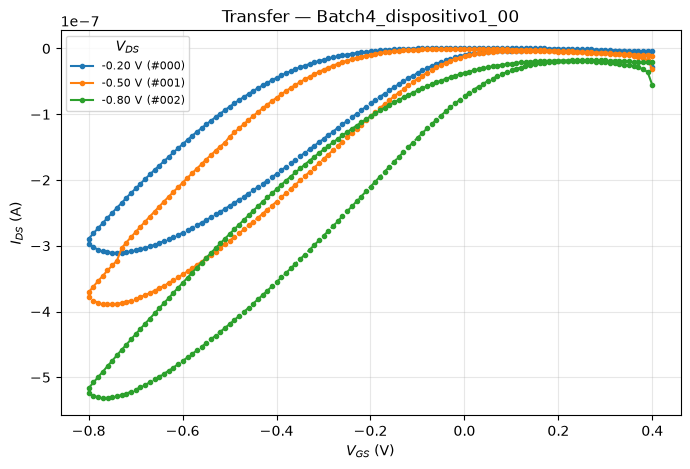

In [26]:
# === Paso 4: graficar datos con funciones de src ===
measurement_name = "Batch4_dispositivo1_00"

plot_transfer(hdf5_path, measurement_name)


['Batch1_dispositivo1_00', 'Batch2_dispositivo1_00', 'Batch3_dispositivo1_00', 'Batch3_dispositivo1_01', 'Batch4_dispositivo1_00', 'Batch4_dispositivo1_03', 'Guido Sample_00', 'Guido Sample_01']
Check the content in this measurments:

[]


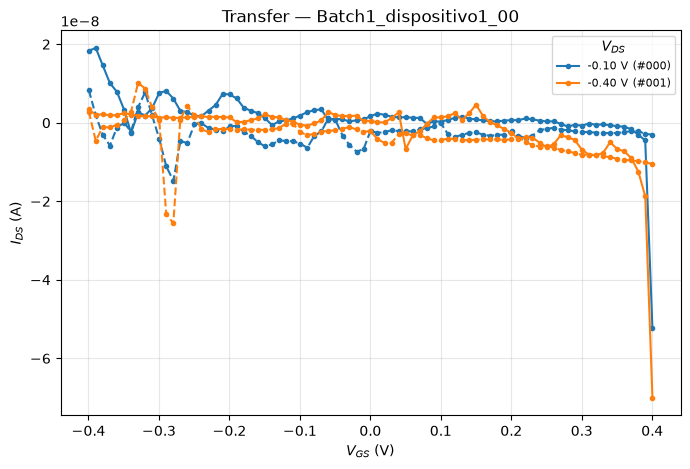

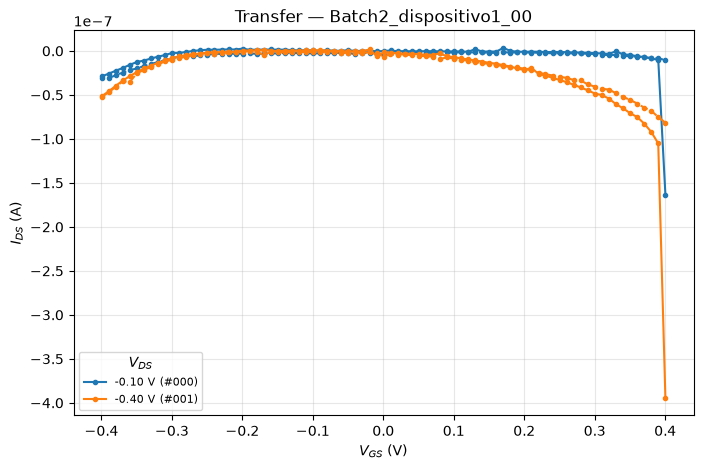

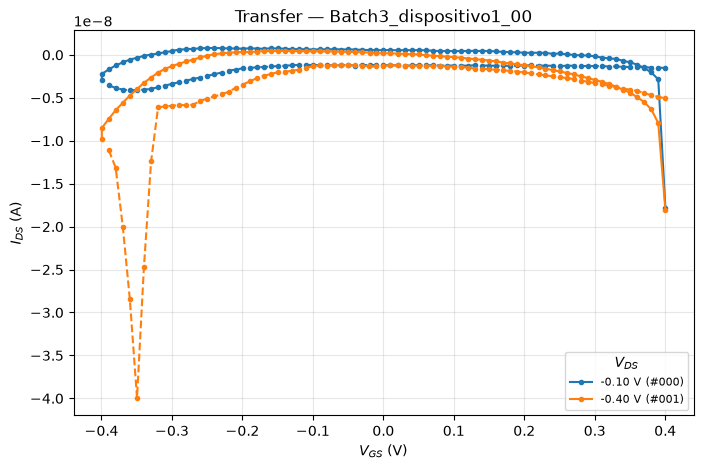

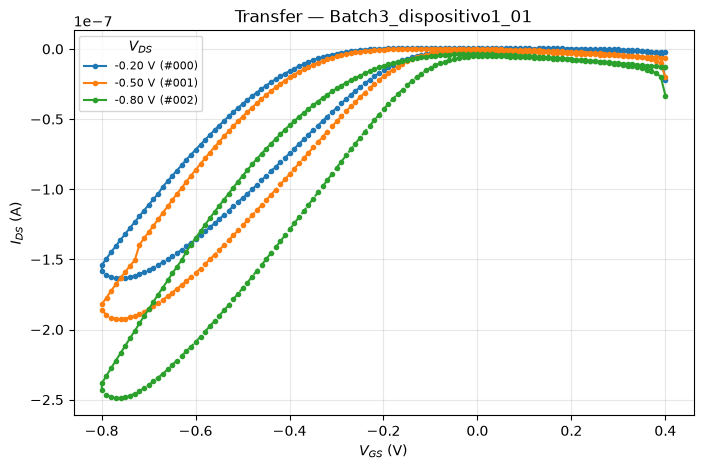

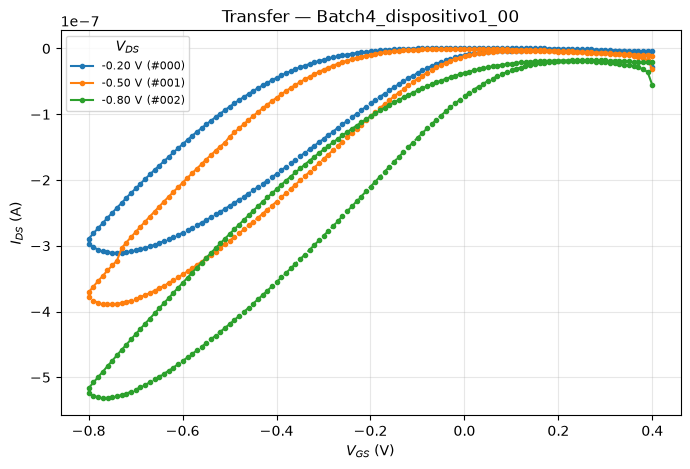

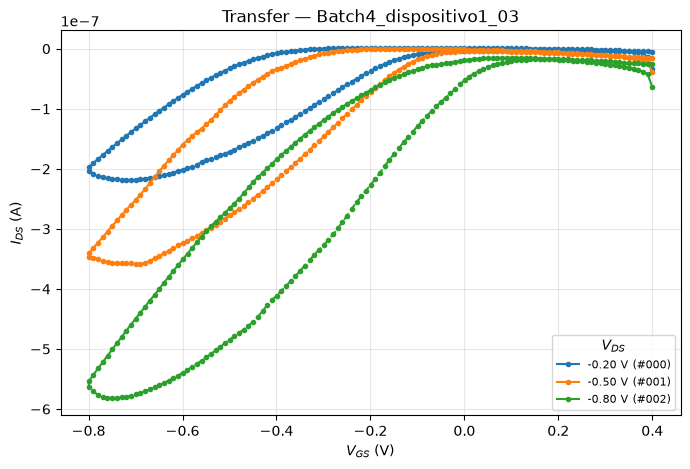

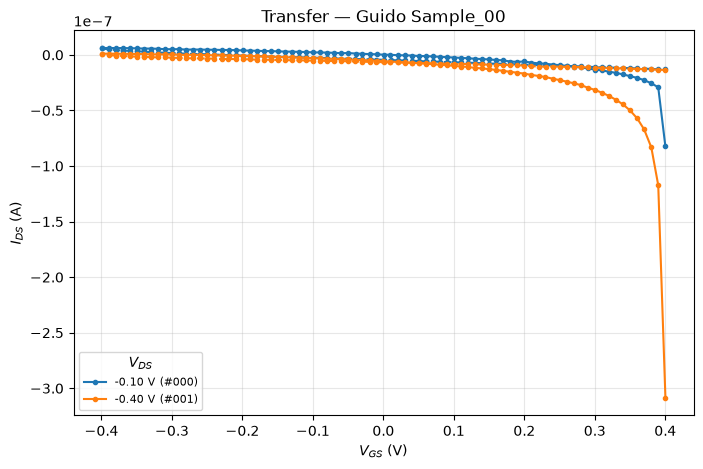

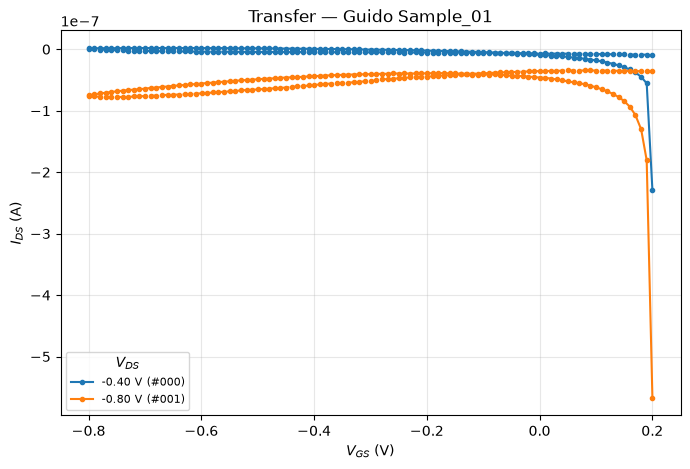

In [ ]:
# === Paso 5: graficar una lista con los batch a observar ===
measurement_list_dic = list_measurements(hdf5_path)

measurement_list_names = [measurement["name"] for measurement in measurement_list_dic if measurement["mode"] == "transfer"]
print(measurement_list_names)

measurements_name_issue = []

for measurement_name in measurement_list_names:
    try:
        plot_transfer(hdf5_path, measurement_name)
    except TypeError:
        print(f"Couldn't plot {measurement_name} due to a TypeError")
        measurements_name_issue.append(measurement_name)
        continue

# Save Configuration

This object controls everything: where to write, which formats, what extras.

## Batch 3 — Dispositivo 1

## Extracción de parámetros

### $V_{th}$ — $\sqrt{I_{DS}}$ (saturación)

### $V_{th}$ — Método lineal

### Subthreshold Swing

### Relación $I_{on}/I_{off}$

## Comparativa entre batches

## Resumen de parámetros por batch

---
### Notas
- Las curvas con nombres inconsistentes se detectan por el atributo `measurement_mode`.
- Usar `vgs_range` en `extract_vth_sqrt` para restringir la región de ajuste.